In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange, BarycentricInterpolator

In [2]:
data = pd.read_csv("punkty.csv", header = None)
data = data.rename(columns={0:"x",1:"y"})
data = data.sort_values(by = "x")

In [3]:
def f(t):
    return 2.14 * (t+1.4) * (t+5.3) * (t-0.44)

In [4]:
xs = np.linspace(min(data["x"]),max(data["x"]), 1000)
ys = f(xs)

In [24]:
coeffs = np.polyfit(data["x"], data["y"], deg=len(data["x"])-1)
p = np.poly1d(coeffs)
interp_ys = p(xs)

C:\Users\kkalu\AppData\Local\Temp\ipykernel_7492\1016211607.py:1: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(data["x"], data["y"], deg=len(data["x"])-1)


In [50]:
p = lagrange(data["x"],data["y"])
p2 = BarycentricInterpolator(data["x"],data["y"])
interp_lagrange = p(xs)
interp_baricentric = p2(xs)

In [7]:
def cross_product(f,g,xs):
    return sum([f(x) * g(x) for x in xs])

In [8]:
def ortogonal_polynomials(xs,n):
    polynomials = [0]*n
    cs = [0]*n
    ds = [0]*n
    lengths = [0]* n # <P_k,P_k>
    polynomials[0] = lambda _ : 1
    lengths[0] = len(xs)
    cs[1] = sum(xs) / lengths[0]
    polynomials[1] = lambda x : x - cs[1]
    lengths[1] = cross_product(polynomials[1],polynomials[1],xs)
    for k in range(2,n):
        cs[k] = cross_product(lambda x : x * polynomials[k-1](x),polynomials[k-1],xs) / lengths[k-1]
        ds[k] = lengths[k-1] / lengths[k-2]
        polynomials[k] = lambda x, p1=polynomials[k-1], p2=polynomials[k-2], c=cs[k], d=ds[k]: \
        (x - c)*p1(x) - d*p2(x)
        lengths[k] = cross_product(polynomials[k],polynomials[k],xs)

    return cs,ds,polynomials,lengths

In [9]:
def optimal_polynomial(xs,ys,n):
    _,_,polynomials,lengths = ortogonal_polynomials(xs,n+1)
    cross_f = lambda f : sum(y * f(x) for x,y in zip(xs, ys))
    w = lambda x : sum([cross_f(polynomials[k]) / lengths[k] * polynomials[k](x) for k in range(n+1)])
    return w


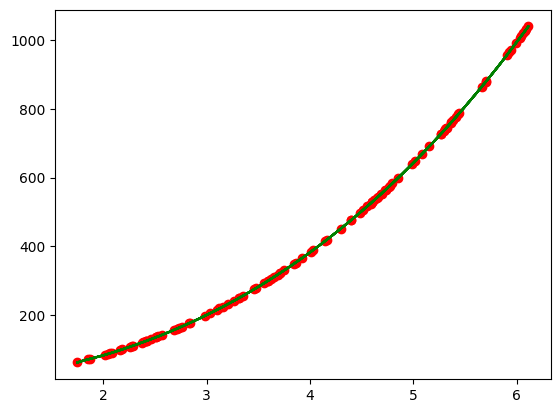

In [21]:
plt.figure()
plt.scatter(data["x"], data["y"], color = "red")
for i in range(2,16):
    optimal_ys = optimal_polynomial(data["x"],data["y"],i)(xs)
    plt.plot(xs,interp_ys, color = "green")
plt.show()

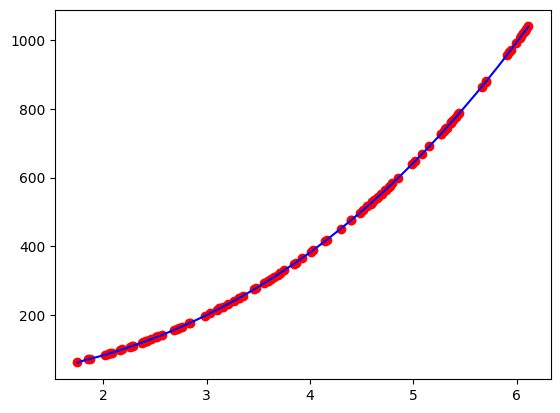

In [23]:
plt.figure()
plt.scatter(data["x"],data["y"], color = "red", label = "D")

plt.plot(xs,interp_ys, color = "blue")
plt.show()

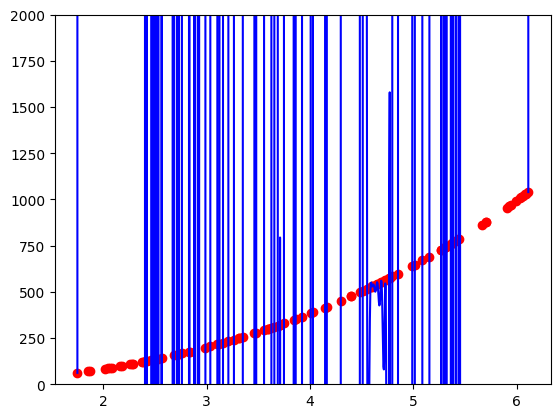

In [52]:
plt.figure()
plt.scatter(data["x"],data["y"], color = "red", label = "D")

plt.plot(xs,interp_baricentric, color = "blue")
plt.ylim(0, 2000)
plt.show()